In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc

In [3]:
def compare_shap(tumor_file, ctc_file, top_n=50):
    tumor = pd.read_csv(tumor_file)
    ctc = pd.read_csv(ctc_file)

    tumor["SHAP"] /= tumor["SHAP"].sum()
    ctc["SHAP"] /= ctc["SHAP"].sum()

    df = tumor.merge(ctc, on="gene", how="outer", suffixes=("_tumor", "_ctc")).fillna(0)

    df["delta_SHAP"] = df["SHAP_ctc"] - df["SHAP_tumor"]

    top_tumor = set(df.nlargest(top_n, "SHAP_tumor")["gene"])
    top_ctc = set(df.nlargest(top_n, "SHAP_ctc")["gene"])

    df["group"] = "Other"
    df.loc[df["gene"].isin(top_tumor & top_ctc), "group"] = "Shared"
    df.loc[df["gene"].isin(top_tumor - top_ctc), "group"] = "Tumor-enriched"
    df.loc[df["gene"].isin(top_ctc - top_tumor), "group"] = "CTC-enriched"

    return df


def make_shap_table(df, n=10):

    ctc = (
        df[df["group"] == "CTC-enriched"]
        .nlargest(n, "delta_SHAP")
    )

    tumor = (
        df[df["group"] == "Tumor-enriched"]
        .nsmallest(n, "delta_SHAP")
    )

    shared = (
        df[df["group"] == "Shared"]
        .assign(mean_SHAP=lambda x: (
            x["SHAP_tumor"] + x["SHAP_ctc"]
        ) / 2)
        .nlargest(n, "mean_SHAP")
    )

    table = pd.concat([ctc, shared, tumor])
    table = table.sort_values(by="mean_SHAP", ascending=False)

    table = table[
        [
            "gene",
            "group",
            "SHAP_tumor",
            "SHAP_ctc",
            "delta_SHAP"
        ]
    ]

    table.to_csv("feature_importance/SHAP_top_features.csv", index=False)

    return table

In [4]:
lgb = compare_shap(
    "feature_importance/lightgbm_shap_values_tumor_test_fixed.csv",
    "feature_importance/lightgbm_shap_values_ctc_test_fixed.csv",
    top_n=10
)
lgb.to_csv("feature_importance/lightgbm_ctc_tumor_shap_values_fixed.csv")

lgb_table = make_shap_table(lgb, n=10)
lgb_table

,gene,group,SHAP_tumor,SHAP_ctc,delta_SHAP
165,RPL10,Shared,0.398325,0.328402,-0.069923
5,ACTB,Shared,0.253696,0.329346,0.075650
167,RPL13,Shared,0.153541,0.142924,-0.010616
61,EEF1A1,Shared,0.113425,0.107076,-0.006349
174,RPL41,Shared,0.060390,0.048635,-0.011755
171,RPL22,Shared,0.001406,0.001454,0.000048
34,CFL1,Shared,0.001236,0.001455,0.000218
64,EIF4G2,CTC-enriched,0.000610,0.001468,0.000858
209,TMBIM6,CTC-enriched,0.000773,0.001433,0.000659
99,HLA-C,CTC-enriched,0.001049,0.001535,0.000486


In [5]:
xgb = compare_shap(
    "feature_importance/xgboost_shap_values_tumor_test_fixed.csv",
    "feature_importance/xgboost_shap_values_ctc_test_fixed.csv",
    top_n=10
)
xgb.to_csv("feature_importance/xgboost_ctc_tumor_shap_values_fixed.csv")

xgb_table = make_shap_table(xgb, n=10)
xgb_table

,gene,group,SHAP_tumor,SHAP_ctc,delta_SHAP
9,EEF1A1,Shared,0.298780,0.245324,-0.053456
15,RPL13,Shared,0.267002,0.276840,0.009838
17,RPL41,Shared,0.173798,0.142772,-0.031027
14,RPL10,Shared,0.150958,0.124070,-0.026887
4,ACTB,Shared,0.054561,0.097596,0.043035
18,RPLP0,Shared,0.024141,0.014655,-0.009486
16,RPL19,Shared,0.010169,0.005647,-0.004523
10,EIF1,Shared,0.004661,0.007779,0.003118
5,ADIPOR1,CTC-enriched,0.000015,0.053134,0.053119
20,SLC4A1,CTC-enriched,0.000002,0.010957,0.010955


In [27]:
consensus = (
    lgb[["gene", "group"]]
    .rename(columns={"group": "LightGBM"})
    .merge(
        xgb[["gene", "group"]]
        .rename(columns={"group": "XGBoost"}),
        on="gene",
        how="outer"
    )
    .fillna("Other")
)

consensus["Consensus"] = consensus.apply(
    lambda row: row["LightGBM"]
    if row["LightGBM"] == row["XGBoost"]
    else "No consensus",
    axis=1
)

consensus.to_csv("SHAP_consensus_table.csv", index=False)

consensus

,gene,LightGBM,XGBoost,Consensus
0,A1BG,Other,Other,Other
1,A2M,Other,Other,Other
2,AADAT,Other,Other,Other
3,AASDH,Other,Other,Other
4,ABCA4,Other,Other,Other
...,...,...,...,...
249,ZFC3H1,Other,Other,Other
250,ZFHX3,Other,Other,Other
251,ZFYVE19,Other,Other,Other
252,ZNF138,Other,Other,Other


In [28]:
def show_importance(top, ranked):
    genes = top["gene"]

    out = ranked[ranked["gene"].isin(genes)][[
        "gene",
        "SHAP_tumor_lgb", "SHAP_ctc_lgb",
        "SHAP_tumor_xgb", "SHAP_ctc_xgb",
        "delta_SHAP_lgb", "delta_SHAP_xgb"
    ]].copy()

    out["mean_importance"] = out[[
        "SHAP_tumor_lgb", "SHAP_ctc_lgb",
        "SHAP_tumor_xgb", "SHAP_ctc_xgb"
    ]].mean(axis=1)

    return out.sort_values("mean_importance", ascending=False)



In [18]:
# Połączenie wyników LightGBM i XGBoost
ranked = (
    lgb[["gene", "group", "SHAP_tumor", "SHAP_ctc", "delta_SHAP"]]
    .merge(
        xgb[["gene", "group", "SHAP_tumor", "SHAP_ctc", "delta_SHAP"]],
        on="gene",
        how="outer",
        suffixes=("_lgb", "_xgb")
    )
    .fillna(0)
)

# ============================================================
# SHARED
# strict consensus: gen jest Shared w obu modelach
# ============================================================

shared = ranked[
    (ranked["group_lgb"] == "Shared") &
    (ranked["group_xgb"] == "Shared")
].copy()

shared["score_lgb"] = (
    (shared["SHAP_tumor_lgb"] + shared["SHAP_ctc_lgb"]) / 2
).rank(pct=True)

shared["score_xgb"] = (
    (shared["SHAP_tumor_xgb"] + shared["SHAP_ctc_xgb"]) / 2
).rank(pct=True)

shared["consensus_score"] = (
    shared["score_lgb"] + shared["score_xgb"]
) / 2

top_shared = shared.nlargest(10, "consensus_score")


# geny należące do strict Shared consensus
shared_genes = set(shared["gene"])

# ============================================================
# CTC-specific
# delta > 0 w obu modelach + NIE Shared
# ============================================================

ctc = ranked[
    (ranked["delta_SHAP_lgb"] > 0) &
    (ranked["delta_SHAP_xgb"] > 0) &
    (~ranked["gene"].isin(shared_genes))
].copy()

ctc["score_lgb"] = ctc["delta_SHAP_lgb"].rank(pct=True)
ctc["score_xgb"] = ctc["delta_SHAP_xgb"].rank(pct=True)

ctc["consensus_score"] = (
    ctc["score_lgb"] + ctc["score_xgb"]
) / 2

top_ctc = ctc.nlargest(10, "consensus_score")


# ============================================================
# Tumor-specific
# delta < 0 w obu modelach + NIE Shared
# ============================================================

tumor = ranked[
    (ranked["delta_SHAP_lgb"] < 0) &
    (ranked["delta_SHAP_xgb"] < 0) &
    (~ranked["gene"].isin(shared_genes))
].copy()

tumor["score_lgb"] = (-tumor["delta_SHAP_lgb"]).rank(pct=True)
tumor["score_xgb"] = (-tumor["delta_SHAP_xgb"]).rank(pct=True)

tumor["consensus_score"] = (
    tumor["score_lgb"] + tumor["score_xgb"]
) / 2

top_tumor = tumor.nlargest(10, "consensus_score")

# ============================================================
# Wyniki
# ============================================================

shared_final = show_importance(top_shared, ranked)
ctc_final = show_importance(top_ctc, ranked)
tumor_final = show_importance(top_tumor, ranked)

print(shared_final)
print(ctc_final)
print(tumor_final)


# # zapis
# top_shared.to_csv(
#     "feature_importance/top10_shared_consensus.csv",
#     index=False
# )

# top_ctc.to_csv(
#     "feature_importance/top10_ctc_consensus.csv",
#     index=False
# )

# top_tumor.to_csv(
#     "feature_importance/top10_tumor_consensus.csv",
#     index=False
# )

       gene  SHAP_tumor_lgb  SHAP_ctc_lgb  SHAP_tumor_xgb  SHAP_ctc_xgb  \
177   RPL10        0.398325      0.328402        0.150958      0.124070   
179   RPL13        0.153541      0.142924        0.267002      0.276840   
69   EEF1A1        0.113425      0.107076        0.298780      0.245324   
9      ACTB        0.253696      0.329346        0.054561      0.097596   
187   RPL41        0.060390      0.048635        0.173798      0.142772   

     delta_SHAP_lgb  delta_SHAP_xgb  mean_importance  
177       -0.069923       -0.026887         0.250439  
179       -0.010616        0.009838         0.210077  
69        -0.006349       -0.053456         0.191151  
9          0.075650        0.043035         0.183800  
187       -0.011755       -0.031027         0.106399  
Empty DataFrame
Columns: [gene, SHAP_tumor_lgb, SHAP_ctc_lgb, SHAP_tumor_xgb, SHAP_ctc_xgb, delta_SHAP_lgb, delta_SHAP_xgb, mean_importance]
Index: []
      gene  SHAP_tumor_lgb  SHAP_ctc_lgb  SHAP_tumor_xgb  SHAP_ctc_x

In [29]:
plot_df = pd.concat([
    top_shared.assign(group="Shared"),
    top_ctc.assign(group="CTC-specific"),
    top_tumor.assign(group="Tumor-specific")
])[["gene", "group"]]

plot_df = plot_df.merge(
    ranked[[
        "gene",
        "SHAP_tumor_lgb",
        "SHAP_ctc_lgb",
        "SHAP_tumor_xgb",
        "SHAP_ctc_xgb"
    ]],
    on="gene"
)



adata_test = sc.read_h5ad("./ready_data/test_tumor_fixed.h5ad")
adata_test_ctc = sc.read_h5ad("./ready_data/ctc_normalized_data_fixed.h5ad")
adata_test_pbmc = sc.read_h5ad("./ready_data/test_healthy_fixed.h5ad")

genes = plot_df["gene"].tolist()

plot_df["Expr_tumor"] = np.asarray(
    adata_test[:, genes].X.mean(axis=0)
).ravel()

plot_df["Expr_ctc"] = np.asarray(
    adata_test_ctc[:, genes].X.mean(axis=0)
).ravel()

plot_df["Expr_pbmc"] = np.asarray(
    adata_test_pbmc[:, genes].X.mean(axis=0)
).ravel()

cols = [
    "SHAP_tumor_lgb",
    "SHAP_ctc_lgb",
    "SHAP_tumor_xgb",
    "SHAP_ctc_xgb"
]

labels = [
    "LightGBM\nTumor",
    "LightGBM\nCTC",
    "XGBoost\nTumor",
    "XGBoost\nCTC"
]

expr_cols = [
    "Expr_pbmc",
    "Expr_tumor",
    "Expr_ctc"
]

expr_labels = [
    "PBMC",
    "Tumor",
    "CTC"
]

vmax = plot_df[cols].to_numpy().max()
expr_min = plot_df[expr_cols].to_numpy().min()
expr_max = plot_df[expr_cols].to_numpy().max()

def plot_group(group):
    df = plot_df[plot_df["group"] == group]

    shap_matrix = df[cols].values
    expr_matrix = df[expr_cols].values

    filename = group.lower().replace("-", "_").replace(" ", "_")

    # =========================
    # SHAP heatmap
    # =========================
    fig_shap, ax = plt.subplots(figsize=(6.5, 4.5))

    im = ax.imshow(
        shap_matrix,
        aspect="auto",
        cmap="Blues",
        vmin=0,
        vmax=vmax
    )

    ax.set_yticks(range(len(df)))
    ax.set_yticklabels(df["gene"])

    ax.set_xticks(range(4))
    ax.set_xticklabels(labels)

    ax.set_title(
        f"{group} genes - SHAP values",
        fontsize=14,
        fontweight="bold"
    )

    for i in range(shap_matrix.shape[0]):
        for j in range(shap_matrix.shape[1]):
            value = shap_matrix[i, j]

            ax.text(
                j, i,
                f"{value:.3f}",
                ha="center",
                va="center",
                fontsize=8,
                color="white" if value > vmax * 0.5 else "black"
            )

    fig_shap.colorbar(
        im,
        ax=ax,
        label="Normalized mean |SHAP|"
    )

    fig_shap.tight_layout()

    fig_shap.savefig(
        f"feature_importance/{filename}_shap_fixed.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.close(fig_shap)


    # =========================
    # Expression heatmap
    # =========================
    fig_expr, ax = plt.subplots(figsize=(5.5, 4.5))

    im = ax.imshow(
        expr_matrix,
        aspect="auto",
        cmap="Greens",
        vmin=expr_min,
        vmax=expr_max
    )

    ax.set_yticks(range(len(df)))
    ax.set_yticklabels(df["gene"])

    ax.set_xticks(range(3))
    ax.set_xticklabels(expr_labels)

    ax.set_title(
        f"{group} genes - expression",
        fontsize=14,
        fontweight="bold"
    )

    for i in range(expr_matrix.shape[0]):
        for j in range(expr_matrix.shape[1]):
            value = expr_matrix[i, j]

            ax.text(
                j, i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=8,
                color="white" if value > expr_max * 0.5 else "black"
            )

    fig_expr.colorbar(
        im,
        ax=ax,
        label="Mean expression"
    )

    fig_expr.tight_layout()

    fig_expr.savefig(
        f"feature_importance/{filename}_expression_fixed.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.close(fig_expr)

plot_group("Shared")
plot_group("CTC-specific")
plot_group("Tumor-specific")

/tmp/ipykernel_5882/605059168.py:81: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  im = ax.imshow(
/tmp/ipykernel_5882/605059168.py:136: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  im = ax.imshow(


Number of unique genes: 20
['RPL10', 'ACTB', 'RPL13', 'EEF1A1', 'RPL41', 'RPL22', 'CFL1', 'EIF4G2', 'TMBIM6', 'HLA-C', 'RPS19', 'TPT1', 'HNRNPA2B1', 'RPLP0', 'RPL19', 'EIF1', 'ADIPOR1', 'SLC4A1', 'FTH1', 'RPLP1']
Genes used: 20
Missing genes: []
         gene      PBMC     Tumor       CTC
0       RPL10  0.000000  3.881265  5.759857
1        ACTB  0.020272  3.364303  8.096376
2       RPL13  0.000000  3.380579  5.161112
3      EEF1A1  0.000000  3.931524  6.507726
4       RPL41  0.000000  3.137867  4.514608
5       RPL22  0.000000  2.477378  3.716777
6        CFL1  0.008024  2.259395  5.974259
7      EIF4G2  0.008960  0.866872  5.599960
8      TMBIM6  0.030512  1.341345  5.930578
9       HLA-C  0.228467  1.607431  5.575510
10      RPS19  0.000000  3.536602  5.550730
11       TPT1  0.000780  3.140510  6.323800
12  HNRNPA2B1  0.007513  1.750023  5.577746
13      RPLP0  0.000000  3.215870  5.696309
14      RPL19  0.000000  3.288552  5.875987
15       EIF1  0.000000  2.252214  6.415666
16    

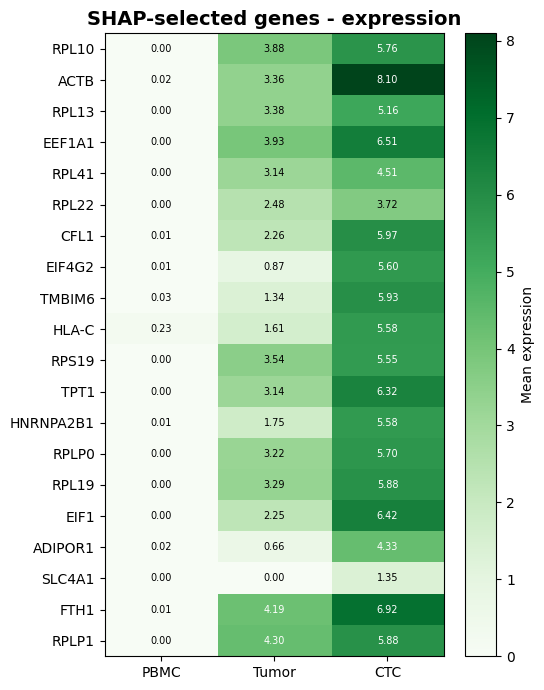

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc


# ============================================================
# 1. Geny z obu tabel SHAP
#    zachowujemy kolejność: najpierw LightGBM,
#    potem nowe geny z XGBoost
# ============================================================

genes = list(dict.fromkeys(
    lgb_table["gene"].tolist() +
    xgb_table["gene"].tolist()
))

print("Number of unique genes:", len(genes))
print(genes)


# ============================================================
# 2. Wczytanie danych
# ============================================================

adata_tumor = sc.read_h5ad(
    "./ready_data/test_tumor_fixed.h5ad"
)

adata_ctc = sc.read_h5ad(
    "./ready_data/ctc_normalized_data_fixed.h5ad"
)

adata_pbmc = sc.read_h5ad(
    "./ready_data/test_healthy_fixed.h5ad"
)


# ============================================================
# 3. Kontrola, czy geny są obecne we wszystkich zbiorach
# ============================================================

genes_present = [
    gene for gene in genes
    if gene in adata_tumor.var_names
    and gene in adata_ctc.var_names
    and gene in adata_pbmc.var_names
]

missing_genes = [
    gene for gene in genes
    if gene not in genes_present
]

print("Genes used:", len(genes_present))
print("Missing genes:", missing_genes)


# ============================================================
# 4. Średnia ekspresja
# ============================================================

expr_df = pd.DataFrame({
    "gene": genes_present,

    "PBMC": np.asarray(
        adata_pbmc[:, genes_present].X.mean(axis=0)
    ).ravel(),

    "Tumor": np.asarray(
        adata_tumor[:, genes_present].X.mean(axis=0)
    ).ravel(),

    "CTC": np.asarray(
        adata_ctc[:, genes_present].X.mean(axis=0)
    ).ravel()
})


print(expr_df)


# zapis tabeli
expr_df.to_csv(
    "feature_importance/LGB_XGB_selected_genes_expression.csv",
    index=False
)


# ============================================================
# 5. Heatmap
# ============================================================

expr_matrix = expr_df[
    ["PBMC", "Tumor", "CTC"]
].to_numpy()

fig, ax = plt.subplots(
    figsize=(5.5, max(5, len(expr_df) * 0.35))
)

im = ax.imshow(
    expr_matrix,
    aspect="auto",
    cmap="Greens"
)

ax.set_yticks(
    np.arange(len(expr_df))
)

ax.set_yticklabels(
    expr_df["gene"]
)

ax.set_xticks(
    np.arange(3)
)

ax.set_xticklabels(
    ["PBMC", "Tumor", "CTC"]
)

ax.set_title(
    "SHAP-selected genes - expression",
    fontsize=14,
    fontweight="bold"
)


# ============================================================
# 6. Wartości liczbowe na heatmapie
# ============================================================

expr_max = expr_matrix.max()

for i in range(expr_matrix.shape[0]):
    for j in range(expr_matrix.shape[1]):

        value = expr_matrix[i, j]

        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=7,
            color="white" if value > expr_max * 0.5 else "black"
        )


fig.colorbar(
    im,
    ax=ax,
    label="Mean expression"
)

fig.tight_layout()

fig.savefig(
    "feature_importance/LGB_XGB_selected_genes_expression.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()